In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [2]:
%connect_info

{"key":"10d5532f-d0f6-46ce-b8e6-66540ec8e033","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9010,"control_port":9011,"shell_port":9012,"stdin_port":9013,"iopub_port":9014,"kernel_name":"python3115jvsc74a57bd0e51a11a35a9cffe10dbeeadb5683ca5855e70b329073972aeeab17b98f2e31e9"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing c:\Users\Ngo_Duc_Phu\AppData\Roaming\jupyter\runtime\kernel-v3e40710eb8dd1b544e7fa121ab582bdafa46396a8.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


In [5]:
#Import the date from Full_Dataset.csv

df_all = pd.read_csv('Full_Dataset.csv', header=0)
df_all.rename(columns={'Date': 'time'}, inplace=True)
df_all['time'] = pd.to_datetime(df_all['time'], dayfirst=True)
df_all.set_index('time', inplace=True)

df_all = df_all.groupby(level=0).mean()
data = df_all[['Price_BE', 'Solar_BE', 'Wind_BE', 'Load_BE']].resample('1h').mean().ffill()
data.columns = ['belpex', 'solar', 'wind', 'load']
# data contains: belpex, solar, wind, load

# Define lookback window
lookback = 7   # use past 7 days to predict next day

# Build 3D input array
features = ['belpex', 'solar', 'wind', 'load']
n_features = len(features)

X_lstm, Y_lstm = [], []

# Scale raw data first
scaler_lstm_x = StandardScaler()
scaler_lstm_y = StandardScaler()

data_scaled = data.copy()
data_scaled[features] = scaler_lstm_x.fit_transform(data[features])
price_scaled = scaler_lstm_y.fit_transform(
    data['belpex'].values.reshape(-1, 1)
)

days = len(data) // 24

for d in range(lookback, days):
    # Past 7 days of all features (hourly)
    past = data_scaled[features].values[(d-lookback)*24 : d*24]
    # Shape: (lookback×24, n_features) = (168, 4)
    
    # Next 24 hours of prices
    future = price_scaled[d*24 : (d+1)*24]
    # Shape: (24, 1)
    
    X_lstm.append(past)
    Y_lstm.append(future.flatten())

X_lstm = np.array(X_lstm)   # shape: (n_days, 168, 4)
Y_lstm = np.array(Y_lstm)   # shape: (n_days, 24)

print(f"X shape: {X_lstm.shape}")
print(f"Y shape: {Y_lstm.shape}")

X shape: (1874, 168, 4)
Y shape: (1874, 24)


In [6]:
from sklearn.model_selection import train_test_split

# Same 70/15/15 split as your ANN
X_tv, X_test, Y_tv, Y_test = train_test_split(
    X_lstm, Y_lstm, test_size=0.15, shuffle=False
)
X_train, X_val, Y_train, Y_val = train_test_split(
    X_tv, Y_tv, test_size=0.176, shuffle=False
)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

Train: (1311, 168, 4)
Val:   (281, 168, 4)
Test:  (282, 168, 4)


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_lstm = Sequential([
    # First LSTM layer — return sequences for stacking
    LSTM(64, 
         return_sequences=True, 
         input_shape=(168, 4)),   # (timesteps, features)
    Dropout(0.2),
    
    # Second LSTM layer
    LSTM(32, 
         return_sequences=False),
    Dropout(0.2),
    
    # Output layer — 24 hourly prices
    Dense(24, activation='linear')
])

model_lstm.compile(
    loss='mae',
    optimizer=Adam(learning_rate=0.001),
    metrics=['mae']
)

model_lstm.summary()

c:\Users\Ngo_Duc_Phu\Downloads\Python_code\Smart_distribution_project\SmartDistributionSystems\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 168, 64)        │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,872 (120.59 KB)

 Trainable params: 30,872 (120.59 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#Training using Callbacks (Not sure how does it work yet)
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    )
]

history_lstm = model_lstm.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - loss: 0.6013 - mae: 0.6013 - val_loss: 0.2852 - val_mae: 0.2852 - learning_rate: 0.0010
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.4021 - mae: 0.4021 - val_loss: 0.2529 - val_mae: 0.2529 - learning_rate: 0.0010
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.3407 - mae: 0.3407 - val_loss: 0.2478 - val_mae: 0.2478 - learning_rate: 0.0010
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.3179 - mae: 0.3179 - val_loss: 0.2417 - val_mae: 0.2417 - learning_rate: 0.0010
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 0.3133 - mae: 0.3133 - val_loss: 0.2381 - val_mae: 0.2381 - learning_rate: 0.0010
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.2980 - mae: 0.2980 - val_loss: 0.2351 - val_mae: 0.2351 - learning_rate: 0.0010
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.2934 - mae: 0.2934 - val_loss: 0.2372 - val_mae: 0.2372 - learning_rate: 0.0010
Epoch 

In [35]:
#Update the parameters and keep training
model_lstm.compile(
    loss='mae',
    optimizer=Adam(learning_rate=0.000001),
    metrics=['mae']
)

history_lstm = model_lstm.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - loss: 0.2434 - mae: 0.2434 - val_loss: 0.2136 - val_mae: 0.2136 - learning_rate: 1.0000e-06
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.2456 - mae: 0.2456 - val_loss: 0.2137 - val_mae: 0.2137 - learning_rate: 1.0000e-06
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.2449 - mae: 0.2449 - val_loss: 0.2137 - val_mae: 0.2137 - learning_rate: 1.0000e-06
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.2453 - mae: 0.2453 - val_loss: 0.2137 - val_mae: 0.2137 - learning_rate: 1.0000e-06
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.2432 - mae: 0.2432 - val_loss: 0.2138 - val_mae: 0.2138 - learning_rate: 1.0000e-06
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.2422 - mae: 0.2422 - val_loss: 0.2138 - val_mae: 0.2138 - learning_rate: 1.0000e-06
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 0.2473 - mae: 0.2473 - val_loss: 0.2138 - val_mae: 0.2138 - lear

In [36]:
# Generate predictions
pred_scaled = model_lstm.predict(X_test)

# Inverse transform
pred_real = scaler_lstm_y.inverse_transform(pred_scaled)
actual_real = scaler_lstm_y.inverse_transform(Y_test)

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(actual_real, pred_real)
rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
mask = actual_real != 0
mape = np.mean(np.abs(
    (actual_real[mask] - pred_real[mask]) / actual_real[mask]
)) * 100

smape = np.mean(2 * np.abs(actual_real - pred_real) / (np.abs(actual_real) + np.abs(pred_real))) * 100
print("\n--- LSTM Performance ---")
print(f"MAE:  {mae:.2f}  €/MWh")
print(f"RMSE: {rmse:.2f} €/MWh")
print(f"MAPE yeah this is wrong: {mape:.2f}%")
print(f"sMAPE: {smape:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step

--- LSTM Performance ---
MAE:  18.14  €/MWh
RMSE: 25.92 €/MWh
MAPE yeah this is wrong: 1608883861741643.50%
sMAPE: 35.74%


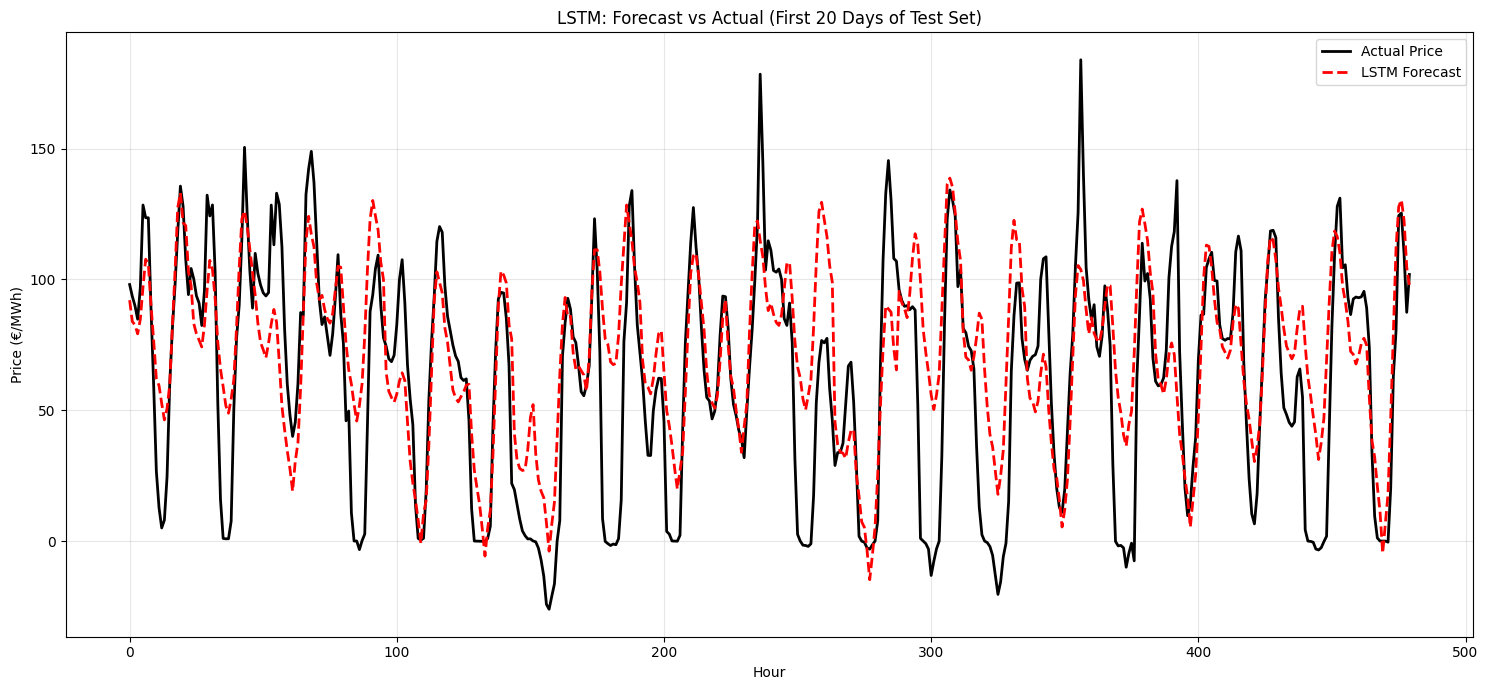

In [37]:
import matplotlib.pyplot as plt

n_plot = 72  # first 3 days

plt.figure(figsize=(15, 7))
plt.plot(actual_real[:20].flatten(),
         label='Actual Price',
         color='black', linewidth=2)
plt.plot(pred_real[:20].flatten(),
         label='LSTM Forecast',
         color='red', linestyle='--', linewidth=2)

plt.title('LSTM: Forecast vs Actual (First 20 Days of Test Set)')
plt.xlabel('Hour')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#Save the model
model_lstm.save("./trained_model/LTSM_model_1.keras")

#Save the scalers because they are critical to the model usage
import pickle
with open('./trained_model/LTSM_scaler_x.pkl', 'wb') as f:
    pickle.dump(scaler_lstm_x, f)

with open('./trained_model/LTSM_scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_lstm_y, f)

In [ ]:
#Reload the model
from tensorflow.keras.models import load_model

model_lstm_loaded = load_model('model_lstm.keras')

#Load the scalers
with open('./trained_model/LTSM_scaler_x.pkl', 'rb') as f:
    scaler_lstm_x = pickle.load(f)

with open('./trained_model/LTSM_scaler_y.pkl', 'rb') as f:
    scaler_lstm_y = pickle.load(f)

# Verify
model_lstm_loaded.summary()

# Predict immediately
X_test_scaled    = scaler_x.transform(X_test)
pred_scaled = model_lstm_loaded.predict(X_test_scaled)
pred_real   = scaler_lstm_y.inverse_transform(pred_scaled)

The model is able to smooth out the average patterns but it fails to accurately capture the troughs. Next thing we want to try is to split this into 3 zones, peak, normal, low for training.

In [ ]:
import numpy as np
import pandas as pd

# ── Use actual (unscaled) prices to define periods ──
actual_train_real = scaler_lstm_y.inverse_transform(Y_train)
actual_test_real  = scaler_lstm_y.inverse_transform(Y_test)

# Daily average price for each training day
daily_avg_price = actual_train_real.mean(axis=1)

# Define thresholds
low_threshold  = np.percentile(daily_avg_price, 33)  # bottom 33%
high_threshold = np.percentile(daily_avg_price, 67)  # top 33%

print(f"Low demand threshold:    < {low_threshold:.2f}  €/MWh")
print(f"Normal demand range:     {low_threshold:.2f} - {high_threshold:.2f} €/MWh")
print(f"High demand threshold:   > {high_threshold:.2f} €/MWh")

# Create masks
is_low_demand    = daily_avg_price < low_threshold
is_high_demand   = daily_avg_price > high_threshold
is_normal_demand = ~is_low_demand & ~is_high_demand

print(f"\nLow demand days:    {is_low_demand.sum()}")
print(f"Normal demand days: {is_normal_demand.sum()}")
print(f"High demand days:   {is_high_demand.sum()}")

Low demand threshold:    < 44.85  €/MWh
Normal demand range:     44.85 - 143.47 €/MWh
High demand threshold:   > 143.47 €/MWh

Low demand days:    131
Normal demand days: 747
High demand days:   433


High demand samples:   433
Low demand samples:    131
Normal demand samples: 747


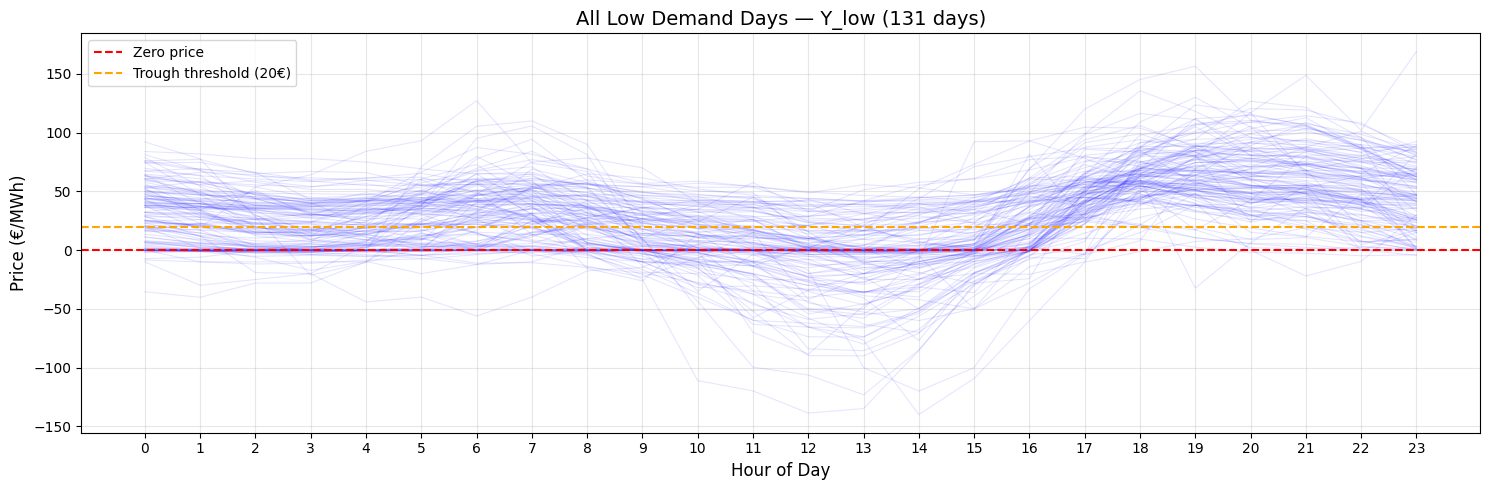

In [55]:
X_high = X_train[is_high_demand]
Y_high = Y_train[is_high_demand]

# ── Low demand ──
X_low  = X_train[is_low_demand]
Y_low  = Y_train[is_low_demand]

# ── Normal demand ──
X_normal = X_train[is_normal_demand]
Y_normal = Y_train[is_normal_demand]

print(f"High demand samples:   {len(X_high)}")
print(f"Low demand samples:    {len(X_low)}")
print(f"Normal demand samples: {len(X_normal)}")

import matplotlib.pyplot as plt
import numpy as np

# ── Inverse transform to real prices ──
actual_low_real = scaler_lstm_y.inverse_transform(Y_low)

# ── Plot all low demand days ──
plt.figure(figsize=(15, 5))
plt.plot(actual_low_real.T,          # transpose so each column = 1 day
         color='blue', alpha=0.1,    # transparent so overlaps visible
         linewidth=0.8)

plt.axhline(y=0,  color='red',    linestyle='--', 
            linewidth=1.5, label='Zero price')
plt.axhline(y=20, color='orange', linestyle='--', 
            linewidth=1.5, label='Trough threshold (20€)')

plt.title(f'All Low Demand Days — Y_low ({len(Y_low)} days)', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Price (€/MWh)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_lstm(input_shape, name):
    model = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(24, activation='linear')
    ], name=name)
    
    model.compile(
        loss=Huber(delta=1.0),
        optimizer=Adam(learning_rate=0.001),
        metrics=['mae']
    )
    return model

input_shape = (X_train.shape[1], X_train.shape[2])

model_high   = build_lstm(input_shape, 'lstm_high_demand')
model_low    = build_lstm(input_shape, 'lstm_low_demand')
model_normal = build_lstm(input_shape, 'lstm_normal_demand')

print("Three models built ✅")

Three models built ✅


c:\Users\Ngo_Duc_Phu\Downloads\Python_code\Smart_distribution_project\SmartDistributionSystems\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=0.00001, verbose=1)
]

print("Training HIGH demand model...")
history_high = model_high.fit(
    X_high, Y_high,
    epochs=100, batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, verbose=1
)

print("\nTraining LOW demand model...")
history_low = model_low.fit(
    X_low, Y_low,
    epochs=100, batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, verbose=1
)

print("\nTraining NORMAL demand model...")
history_normal = model_normal.fit(
    X_normal, Y_normal,
    epochs=100, batch_size=32,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, verbose=1
)

Training HIGH demand model...
Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.8115 - mae: 1.2107 - val_loss: 0.1821 - val_mae: 0.4876 - learning_rate: 0.0010
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - loss: 0.5829 - mae: 0.9429 - val_loss: 0.2091 - val_mae: 0.5472 - learning_rate: 0.0010
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.4470 - mae: 0.7811 - val_loss: 0.1851 - val_mae: 0.4851 - learning_rate: 0.0010
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.3570 - mae: 0.6718 - val_loss: 0.1634 - val_mae: 0.4455 - learning_rate: 0.0010
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - loss: 0.2948 - mae: 0.5979 - val_loss: 0.1668 - val_mae: 0.4524 - learning_rate: 0.0010
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.2708 - mae: 0.5663 - val_loss: 0.1740 - val_mae: 0.4708 - learning_rate: 0.0010
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - loss: 0.2421 - mae: 0.5291 - val_loss: 0.1710 - val_mae: 0.4674

In [56]:
#Retraining the LOW demand model:
model_low.compile(
    loss='mae',
    optimizer=Adam(learning_rate=0.000001),
    metrics=['mae']
)

history_low = model_low.fit(
    X_low, Y_low,
    epochs=100, batch_size=4,
    validation_data=(X_val, Y_val),
    callbacks=callbacks, verbose=1
)

Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - loss: 0.3132 - mae: 0.3132 - val_loss: 0.3413 - val_mae: 0.3413 - learning_rate: 1.0000e-06
Epoch 2/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.3041 - mae: 0.3041 - val_loss: 0.3422 - val_mae: 0.3422 - learning_rate: 1.0000e-06
Epoch 3/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.3150 - mae: 0.3150 - val_loss: 0.3431 - val_mae: 0.3431 - learning_rate: 1.0000e-06
Epoch 4/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.3232 - mae: 0.3232 - val_loss: 0.3440 - val_mae: 0.3440 - learning_rate: 1.0000e-06
Epoch 5/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.3090 - mae: 0.3090 - val_loss: 0.3448 - val_mae: 0.3448 - learning_rate: 1.0000e-06
Epoch 6/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.3107 - mae: 0.3107 - val_loss: 0.3458 - val_mae: 0.3458 - learning_rate: 1.0000e-06
Epoch 7/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.2963 - mae: 0.2963 - val_loss: 0.3466 - val_mae: 0.3466 - lear

In [44]:
def predict_with_routing(X_test, Y_test, 
                          model_high, model_low, model_normal,
                          scaler_lstm_y, low_threshold, high_threshold):
    
    # ── Step 1: Get a rough price estimate using normal model ──
    rough_pred_scaled = model_normal.predict(X_test, verbose=0)
    rough_pred_real   = scaler_lstm_y.inverse_transform(rough_pred_scaled)
    rough_daily_avg   = rough_pred_real.mean(axis=1)
    
    # ── Step 2: Route each day to correct model ──
    final_predictions = np.zeros((len(X_test), 24))
    routing_log       = []
    
    for i in range(len(X_test)):
        avg = rough_daily_avg[i]
        
        if avg < low_threshold:
            pred = model_low.predict(
                X_test[i:i+1], verbose=0)
            routing_log.append('low')
        elif avg > high_threshold:
            pred = model_high.predict(
                X_test[i:i+1], verbose=0)
            routing_log.append('high')
        else:
            pred = model_normal.predict(
                X_test[i:i+1], verbose=0)
            routing_log.append('normal')
        
        final_predictions[i] = pred[0]
    
    # ── Step 3: Inverse scale ──
    predictions_real = scaler_lstm_y.inverse_transform(final_predictions)
    
    # ── Step 4: Routing summary ──
    routing_log = np.array(routing_log)
    print(f"\nRouting Summary:")
    print(f"  High demand:   {(routing_log=='high').sum()} days")
    print(f"  Normal demand: {(routing_log=='normal').sum()} days")
    print(f"  Low demand:    {(routing_log=='low').sum()} days")
    
    return predictions_real, routing_log

# ── Run predictions ──
pred_real, routing = predict_with_routing(
    X_test, Y_test,
    model_high, model_low, model_normal,
    scaler_lstm_y, low_threshold, high_threshold
)


Routing Summary:
  High demand:   0 days
  Normal demand: 267 days
  Low demand:    15 days


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual_real = scaler_lstm_y.inverse_transform(Y_test)

mae  = mean_absolute_error(actual_real, pred_real)
rmse = np.sqrt(mean_squared_error(actual_real, pred_real))
mask = actual_real != 0
mape = np.mean(np.abs(
    (actual_real[mask] - pred_real[mask]) / actual_real[mask]
)) * 100

print("\n--- Routed LSTM Performance ---")
print(f"MAE:  {mae:.2f}  €/MWh")
print(f"RMSE: {rmse:.2f} €/MWh")
print(f"MAPE: {mape:.2f}%")

# ── Evaluate low demand days specifically ──
actual_daily_avg = actual_real.mean(axis=1)
is_low_test      = actual_daily_avg < low_threshold

mae_low  = mean_absolute_error(
    actual_real[is_low_test], pred_real[is_low_test])
rmse_low = np.sqrt(mean_squared_error(
    actual_real[is_low_test], pred_real[is_low_test]))

print(f"\n--- Low Demand Days Specifically ---")
print(f"MAE:  {mae_low:.2f}  €/MWh")
print(f"RMSE: {rmse_low:.2f} €/MWh")


--- Routed LSTM Performance ---
MAE:  20.38  €/MWh
RMSE: 29.16 €/MWh
MAPE: 2568296671404570.50%

--- Low Demand Days Specifically ---
MAE:  28.92  €/MWh
RMSE: 36.67 €/MWh


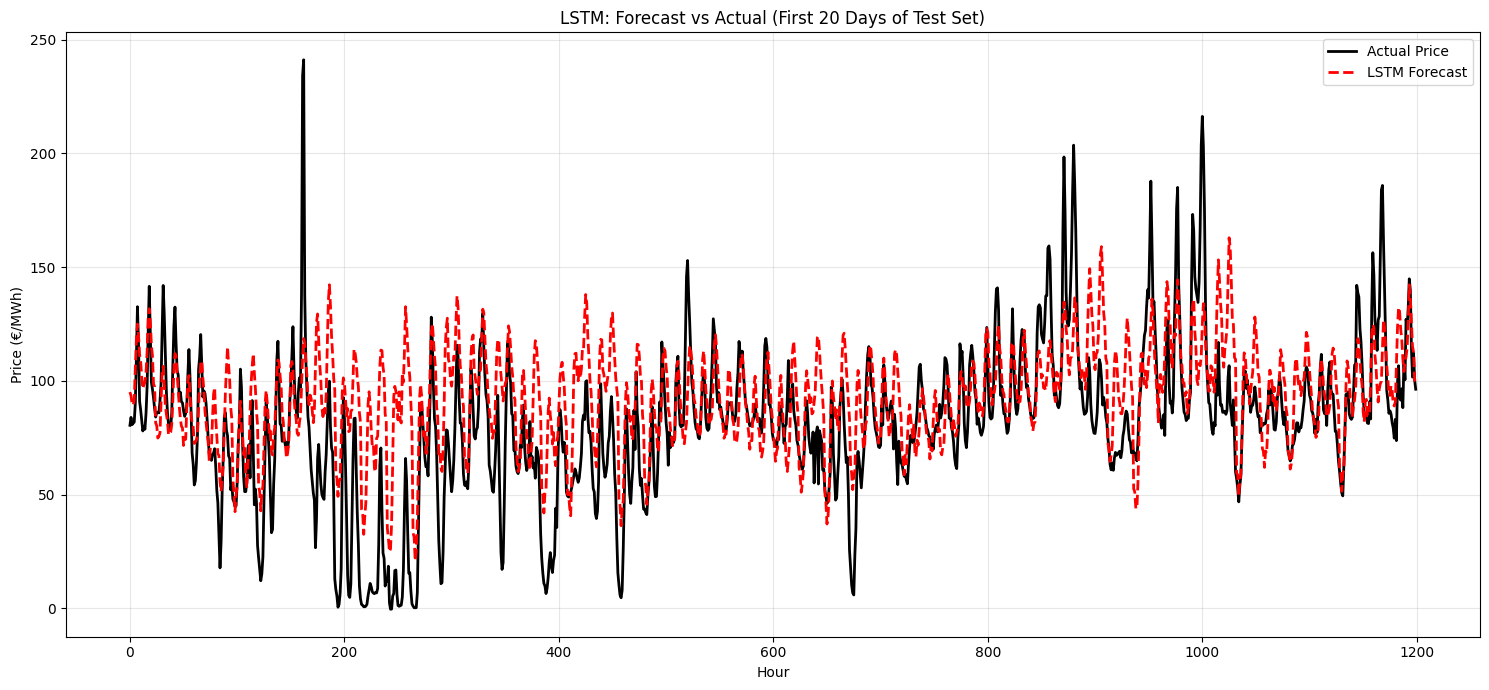

In [59]:
import matplotlib.pyplot as plt

n_plot_start = 150
n_plot = 200  # first 3 days

plt.figure(figsize=(15, 7))
plt.plot(actual_real[n_plot_start:n_plot].flatten(),
         label='Actual Price',
         color='black', linewidth=2)
plt.plot(pred_real[n_plot_start:n_plot].flatten(),
         label='LSTM Forecast',
         color='red', linestyle='--', linewidth=2)

plt.title('LSTM: Forecast vs Actual (First 20 Days of Test Set)')
plt.xlabel('Hour')
plt.ylabel('Price (€/MWh)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [61]:
#Save the model for future use
model_high.save('./trained_model/LSTM_2_high.keras')
model_low.save('./trained_model/LSTM_2_low.keras')
model_normal.save('./trained_model/LSTM_2_normal.keras')

# Save thresholds for future use
import pickle
thresholds = {
    'low_threshold':  low_threshold,
    'high_threshold': high_threshold
}
with open('./trained_model/LSTM_2_demand_thresholds.pkl', 'wb') as f:
    pickle.dump(thresholds, f)

with open('./trained_model/LTSM_2_scaler_x.pkl', 'wb') as f:
    pickle.dump(scaler_lstm_x, f)

with open('./trained_model/LTSM_2_scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_lstm_y, f)

print("All models and thresholds saved ✅")

All models and thresholds saved ✅


In [ ]:
#Reload the model
from tensorflow.keras.models import load_model
import pickle

# ── Load all three models ──
model_high   = load_model('./trained_model/LSTM_2_high.keras')
model_low    = load_model('./trained_model/LSTM_2_low.keras')
model_normal = load_model('./trained_model/LSTM_2_normal.keras')

# ── Load thresholds ──
with open('./trained_model/LSTM_2_thresholds.pkl', 'rb') as f:
    thresholds = pickle.load(f)

low_threshold  = thresholds['low_threshold']
high_threshold = thresholds['high_threshold']

with open('./trained_model/LTSM_2_scaler_lstm_x.pkl', 'rb') as f:
    scaler_lstm_x = pickle.load(f)

with open('./trained_model/LTSM_2_scaler_lstm_y.pkl', 'rb') as f:
    scaler_lstm_y = pickle.load(f)

print("Models loaded ✅")
print(f"Low threshold:  {low_threshold:.2f} €/MWh")
print(f"High threshold: {high_threshold:.2f} €/MWh")